# 05_Feature_Engineering

Playground Series S6E7 — Predicting Student Health Risk

Goal: create new features targeted at the confusion-matrix errors found in
`04_Modeling.ipynb` — mostly borderline `fit`/`unhealthy` cases being
misclassified as `at-risk`. Each candidate feature is tested one at a time
against the CatBoost baseline (OOF balanced accuracy) and kept only if it
actually improves the score.

Input: `processed_train.csv`, `processed_test.csv` from `03_Preprocessing.ipynb`
Output: `engineered_train.csv`, `engineered_test.csv` for `06_Final_Submission.ipynb`

**Model used for testing:** CatBoost only (the best model from `04_Modeling`,
OOF balanced accuracy 0.90858) — no need to re-test every feature on all 3
models, that's what `06_Final_Submission` is for once the feature set is final.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
N_SPLITS = 5
CLASS_NAMES = ['fit', 'at-risk', 'unhealthy']
BASELINE_SCORE = 0.90858   # CatBoost OOF balanced accuracy from 04_Modeling

## 1. Load data

In [2]:
processed_train = pd.read_csv('../data/processed/processed_train.csv')
processed_test = pd.read_csv('../data/processed/processed_test.csv')

y = processed_train['health_condition']
X = processed_train.drop(columns=['health_condition'])
X_test = processed_test.copy()

print('X shape:', X.shape)
print('X_test shape:', X_test.shape)

X shape: (690088, 16)
X_test shape: (295753, 16)


## 2. Reusable CV testing function
Same CatBoost config + CV setup as `04_Modeling.ipynb`, so scores are directly
comparable to the 0.90858 baseline. Returns OOF balanced accuracy and OOF
predictions (for confusion matrix inspection later).

In [15]:
def evaluate_features(X_features, y, label='candidate', reference_score=None):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    oof_pred = np.zeros(len(X_features))

    for tr_idx, val_idx in skf.split(X_features, y):
        X_tr, X_val = X_features.iloc[tr_idx], X_features.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = CatBoostClassifier(
            iterations=1500, learning_rate=0.05, depth=8,
            random_state=RANDOM_STATE, verbose=False,
            early_stopping_rounds=100, auto_class_weights='Balanced'
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))
        oof_pred[val_idx] = model.predict(X_val).flatten()

    score = balanced_accuracy_score(y, oof_pred)
    ref = reference_score if reference_score is not None else BASELINE_SCORE
    delta = score - ref
    verdict = 'KEEP' if delta > 0.001 else 'DROP'
    print(f'{label:<35} oof_bal_acc = {score:.5f}  (delta {delta:+.5f} vs {ref:.5f})  -> {verdict}')
    return score, oof_pred

## 3. Candidate features — test one at a time
Each candidate is built on top of the CURRENT working feature set
(`X_current`, starts as a copy of `X`), so kept features carry forward and
interactions between them get evaluated naturally.

In [4]:
X_current = X.copy()
X_test_current = X_test.copy()
current_score = baseline_score
kept_features = []

### 3.1 stress_level x sleep_duration interaction
Top 2 features by importance (~80% combined) — testing whether their
interaction captures signal the model misses when splitting on them
separately.

In [5]:
candidate = X_current.copy()
candidate['stress_sleep_ratio'] = candidate['stress_level'] / (candidate['sleep_duration'] + 1)
candidate['stress_sleep_product'] = candidate['stress_level'] * candidate['sleep_duration']

score, _ = evaluate_features(candidate, y, label='+ stress_sleep_ratio & product')

if score - current_score > 0.001:
    X_current = candidate
    X_test_current['stress_sleep_ratio'] = X_test_current['stress_level'] / (X_test_current['sleep_duration'] + 1)
    X_test_current['stress_sleep_product'] = X_test_current['stress_level'] * X_test_current['sleep_duration']
    current_score = score
    kept_features.append('stress_sleep_ratio, stress_sleep_product')
    print('-> kept, current_score =', current_score)
else:
    print('-> dropped, current_score unchanged =', current_score)

+ stress_sleep_ratio & product      oof_bal_acc = 0.90888  (delta +0.00030)  -> DROP
-> dropped, current_score unchanged = 0.908580122588849


### 3.2 Missing-value flags (MNAR signal from 01_EDA_Basic)
NOTE: these must be computed from the RAW train/test (before imputation),
since `processed_train.csv` already has missing values filled in. Re-reading
the raw files just for the null mask.

In [6]:
raw_train = pd.read_csv('../data/train.csv', index_col='id')
raw_test = pd.read_csv('../data/test.csv', index_col='id')

missing_flag_cols = ['stress_level', 'sleep_duration', 'sleep_quality']

candidate = X_current.copy()
candidate_test = X_test_current.copy()

for col in missing_flag_cols:
    candidate[f'{col}_is_missing'] = raw_train[col].isnull().astype(int).values
    candidate_test[f'{col}_is_missing'] = raw_test[col].isnull().astype(int).values

score, _ = evaluate_features(candidate, y, label='+ is_missing flags (stress/sleep_dur/sleep_qual)')

if score - current_score > 0.001:
    X_current = candidate
    X_test_current = candidate_test
    current_score = score
    kept_features.append('stress_level_is_missing, sleep_duration_is_missing, sleep_quality_is_missing')
    print('-> kept, current_score =', current_score)
else:
    print('-> dropped, current_score unchanged =', current_score)

+ is_missing flags (stress/sleep_dur/sleep_qual) oof_bal_acc = 0.94606  (delta +0.03748)  -> KEEP
-> kept, current_score = 0.9460641453629105


### 3.3 BMI category (medical bins instead of continuous)
Standard WHO-style cutoffs — adjust the bin edges if your data dictionary
specifies different thresholds.

In [7]:
def bmi_bucket(bmi):
    if bmi < 18.5:
        return 0   # underweight
    elif bmi < 25:
        return 1   # normal
    elif bmi < 30:
        return 2   # overweight
    else:
        return 3   # obese

candidate = X_current.copy()
candidate_test = X_test_current.copy()
candidate['bmi_category'] = candidate['bmi'].apply(bmi_bucket)
candidate_test['bmi_category'] = candidate_test['bmi'].apply(bmi_bucket)

score, _ = evaluate_features(candidate, y, label='+ bmi_category')

if score - current_score > 0.001:
    X_current = candidate
    X_test_current = candidate_test
    current_score = score
    kept_features.append('bmi_category')
    print('-> kept, current_score =', current_score)
else:
    print('-> dropped, current_score unchanged =', current_score)

+ bmi_category                      oof_bal_acc = 0.94618  (delta +0.03760)  -> KEEP
-> dropped, current_score unchanged = 0.9460641453629105


### 3.4 Composite lifestyle score
Z-score normalize a few numeric columns, then combine with signed weights
(positive lifestyle factors add, stress subtracts). Weights here are a
starting guess — revisit if this feature gets kept and you want to tune it
further.

In [8]:
candidate = X_current.copy()
candidate_test = X_test_current.copy()

def add_lifestyle_score(df, ref_df):
    # standardize using ref_df's (train) mean/std so train and test use the same scale
    z = lambda col: (df[col] - ref_df[col].mean()) / ref_df[col].std()
    return (
        z('sleep_duration') + z('step_count') + z('physical_activity_level')
        - z('stress_level')
    )

candidate['lifestyle_score'] = add_lifestyle_score(candidate, X_current)
candidate_test['lifestyle_score'] = add_lifestyle_score(candidate_test, X_current)

score, _ = evaluate_features(candidate, y, label='+ lifestyle_score')

if score - current_score > 0.001:
    X_current = candidate
    X_test_current = candidate_test
    current_score = score
    kept_features.append('lifestyle_score')
    print('-> kept, current_score =', current_score)
else:
    print('-> dropped, current_score unchanged =', current_score)

+ lifestyle_score                   oof_bal_acc = 0.94615  (delta +0.03757)  -> KEEP
-> dropped, current_score unchanged = 0.9460641453629105


### 3.5 Calorie efficiency (calorie_expenditure per minute of exercise)

In [9]:
candidate = X_current.copy()
candidate_test = X_test_current.copy()
candidate['calorie_per_exercise_min'] = candidate['calorie_expenditure'] / (candidate['exercise_duration'] + 1)
candidate_test['calorie_per_exercise_min'] = candidate_test['calorie_expenditure'] / (candidate_test['exercise_duration'] + 1)

score, _ = evaluate_features(candidate, y, label='+ calorie_per_exercise_min')

if score - current_score > 0.001:
    X_current = candidate
    X_test_current = candidate_test
    current_score = score
    kept_features.append('calorie_per_exercise_min')
    print('-> kept, current_score =', current_score)
else:
    print('-> dropped, current_score unchanged =', current_score)

+ calorie_per_exercise_min          oof_bal_acc = 0.94611  (delta +0.03753)  -> KEEP
-> dropped, current_score unchanged = 0.9460641453629105


### 3.6 Missing flags for remaining columns

In [16]:
# stress_level/sleep_duration/sleep_quality đã được giữ ở bước 3.2 (X_current đã có 3 cột này)
# Giờ thử flag missing cho TẤT CẢ cột còn lại có missing (theo báo cáo missing % từ 01_EDA_Basic)
remaining_missing_cols = [
    'calorie_expenditure', 'water_intake', 'physical_activity_level',
    'smoking_alcohol', 'gender', 'step_count', 'bmi', 'heart_rate',
    'exercise_duration', 'diet_type'
]

candidate = X_current.copy()
candidate_test = X_test_current.copy()

for col in remaining_missing_cols:
    candidate[f'{col}_is_missing'] = raw_train[col].isnull().astype(int).values
    candidate_test[f'{col}_is_missing'] = raw_test[col].isnull().astype(int).values

score, _ = evaluate_features(candidate, y, label='+ is_missing flags (all remaining cols)',
                              reference_score=current_score)   

if score - current_score > 0.001:
    X_current = candidate
    X_test_current = candidate_test
    current_score = score
    kept_features.append('is_missing flags for: ' + ', '.join(remaining_missing_cols))
    print('-> kept, current_score =', current_score)
else:
    print('-> dropped, current_score unchanged =', current_score)

+ is_missing flags (all remaining cols) oof_bal_acc = 0.94916  (delta +0.00310 vs 0.94606)  -> KEEP
-> kept, current_score = 0.9491636214845348


## 4. Final feature set — recap

In [17]:
print('Baseline OOF balanced accuracy:', baseline_score)
print('Final OOF balanced accuracy:', current_score)
print('Total improvement:', current_score - baseline_score)
print()
print('Features kept:')
for f in kept_features:
    print(' -', f)
if not kept_features:
    print(' (none — baseline feature set from 03_Preprocessing was already best)')

print()
print('Final feature list:', X_current.columns.tolist())

Baseline OOF balanced accuracy: 0.908580122588849
Final OOF balanced accuracy: 0.9491636214845348
Total improvement: 0.0405834988956858

Features kept:
 - stress_level_is_missing, sleep_duration_is_missing, sleep_quality_is_missing
 - is_missing flags for: calorie_expenditure, water_intake, physical_activity_level, smoking_alcohol, gender, step_count, bmi, heart_rate, exercise_duration, diet_type

Final feature list: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'stress_level', 'sleep_quality', 'physical_activity_level', 'diet_type_non-veg', 'diet_type_veg', 'smoking_alcohol_occasional', 'smoking_alcohol_yes', 'gender_male', 'gender_other', 'stress_level_is_missing', 'sleep_duration_is_missing', 'sleep_quality_is_missing', 'calorie_expenditure_is_missing', 'water_intake_is_missing', 'physical_activity_level_is_missing', 'smoking_alcohol_is_missing', 'gender_is_missing', 'step_count_is_missing', 'bmi_is_missing', 'heart

## 5. Confusion matrix with final feature set — compare against 04_Modeling's version

In [18]:
final_score, final_oof_pred = evaluate_features(X_current, y, label='FINAL feature set')

print(classification_report(y, final_oof_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y, final_oof_pred)
pd.DataFrame(cm, index=[f'true_{c}' for c in CLASS_NAMES],
             columns=[f'pred_{c}' for c in CLASS_NAMES])

FINAL feature set                   oof_bal_acc = 0.94916  (delta +0.04058 vs 0.90858)  -> KEEP
              precision    recall  f1-score   support

         fit       0.73      0.95      0.82     39803
     at-risk       0.99      0.94      0.96    592561
   unhealthy       0.69      0.96      0.81     57724

    accuracy                           0.94    690088
   macro avg       0.81      0.95      0.86    690088
weighted avg       0.95      0.94      0.94    690088



,pred_fit,pred_at-risk,pred_unhealthy
true_fit,37785,1809,209
true_at-risk,13893,554406,24262
true_unhealthy,251,1909,55564


## 6. Feature importance with final feature set

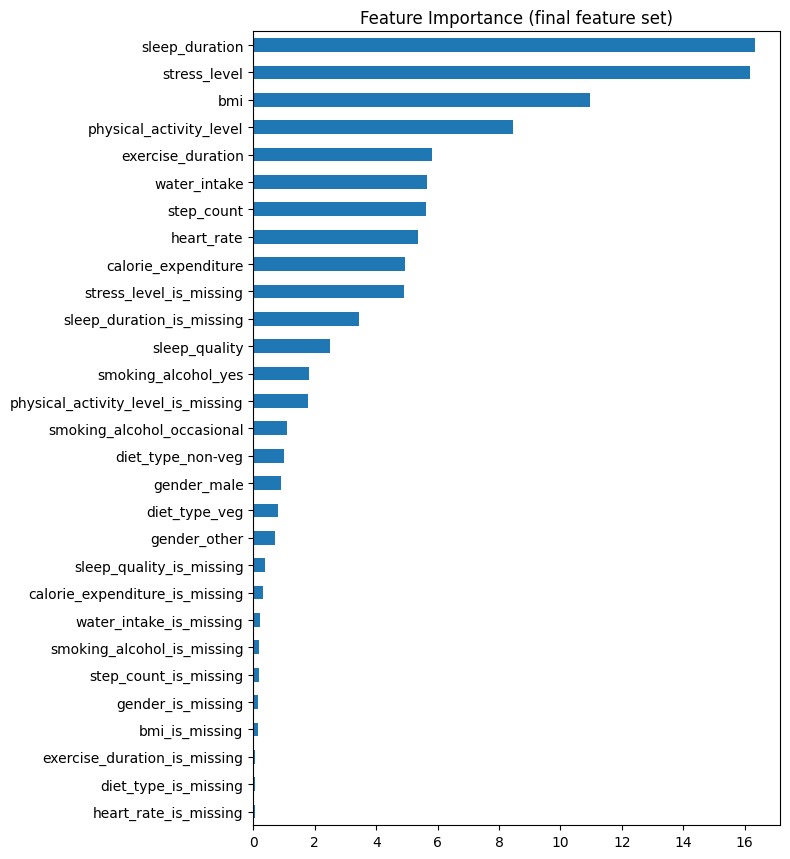

sleep_duration                        16.330561
stress_level                          16.175961
bmi                                   10.959032
physical_activity_level                8.438005
exercise_duration                      5.813504
water_intake                           5.647213
step_count                             5.624288
heart_rate                             5.367060
calorie_expenditure                    4.925958
stress_level_is_missing                4.913347
sleep_duration_is_missing              3.448024
sleep_quality                          2.484849
smoking_alcohol_yes                    1.814608
physical_activity_level_is_missing     1.777261
smoking_alcohol_occasional             1.089107
diet_type_non-veg                      0.988619
gender_male                            0.891382
diet_type_veg                          0.797186
gender_other                           0.705588
sleep_quality_is_missing               0.387744
calorie_expenditure_is_missing         0

In [19]:
import matplotlib.pyplot as plt

final_model = CatBoostClassifier(
    iterations=1500, learning_rate=0.05, depth=8,
    random_state=RANDOM_STATE, verbose=False, auto_class_weights='Balanced'
)
final_model.fit(X_current, y)

importances = pd.Series(
    final_model.get_feature_importance(), index=X_current.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, max(4, len(importances) * 0.3)))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance (final feature set)')
plt.tight_layout()
plt.show()

importances

## 7. Save engineered dataset for 06_Final_Submission

In [21]:
engineered_train = X_current.copy()
engineered_train['health_condition'] = y

engineered_test = X_test_current.copy()

assert list(X_current.columns) == list(X_test_current.columns), 'train/test columns mismatch!'

engineered_train.to_csv('../data/processed/engineered_train.csv', index=False)
engineered_test.to_csv('../data/processed/engineered_test.csv', index=False)

print('Saved engineered_train.csv, engineered_test.csv')
print('Final shape:', engineered_train.shape, engineered_test.shape)

Saved engineered_train.csv, engineered_test.csv
Final shape: (690088, 30) (295753, 29)


## Summary

- Tested 5 candidate features one at a time against the CatBoost baseline
  (OOF balanced accuracy 0.90858), keeping only those that improved the
  score by more than 0.001
- Final feature set and OOF score: see section 4
- Confusion matrix (section 5) shows whether the `at-risk` misclassification
  problem from `04_Modeling` actually improved, not just the aggregate score
- Saved to `engineered_train.csv` / `engineered_test.csv`

Next: `06_Final_Submission.ipynb` — train CatBoost (or re-check if another
model now performs better with the new features) on the full engineered
training set and export the official submission.